# ICS 3202 — Practical Exercise 2: Data Cleaning
**Dataset:** Airplane Crashes Dataset (Kaggle)
**Group members:** Sean Muthomi (190119), Alvin Kyalo (192085), Brian Kipngeno (168049)

Each question below sits in its own cell, per the instructions. Run cells top to bottom.

## Setup: Load the dataset

Download `Airplane_Crashes_and_Fatalities_Since_1908.csv` from Kaggle and upload it to this Colab session (left sidebar → Files → upload, or use `files.upload()` below), then adjust the filename if needed.

In [1]:
# If running in Colab and the file isn't already in the session, uncomment:
# from google.colab import files
# uploaded = files.upload()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Airplane_Crashes_and_Fatalities_Since_1908.csv")
df.head()

ModuleNotFoundError: No module named 'pandas'

## Question 1: Number of rows and columns

In [ ]:
n_rows, n_cols = df.shape
print(f"Rows: {n_rows}")
print(f"Columns: {n_cols}")

Rows: 5268
Columns: 13


## Question 2: Last 75 rows

In [ ]:
df.tail(75)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,05/20/2009,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,NaN,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,05/26/2009,NaN,"Near Isiro, DemocratiRepubliCongo",Service Air,NaN,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,NaN,The cargo plane crashed while on approach to I...
5265,06/01/2009,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,06/07/2009,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,NaN,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...


## Question 3: Missing data — column by column

First, see how much is actually missing, then justify a treatment per column.

In [ ]:
df.isna().sum().sort_values(ascending=False)

,0
Flight #,4199
Time,2219
Route,1707
cn/In,1228
Summary,390
Registration,335
Type,27
Ground,22
Aboard,22
Location,20


**Suggested treatment per column** (typical for this dataset — adjust to what your `isna()` output actually shows):

- **Date** — no missing values (given). Leave as is.
- **Time** — often missing; fill with `"Unknown"` rather than dropping rows, since crash time isn't needed for most later questions and dropping would lose fatality data.
- **Location** — fill with `"Unknown"`; dropping would lose Q4/Q7 data for otherwise-complete rows.
- **Operator** — fill with `"Unknown"` (categorical, non-critical to the numeric questions).
- **Flight #** — mostly missing historically (flight numbering wasn't standard pre-1950s); fill with `"N/A"` rather than drop, since dropping would remove a large share of older, real crashes.
- **Route** — fill with `"Unknown"`; free-text field, low impact on analysis.
- **Type** — fill with `"Unknown"`; a handful of missing aircraft types shouldn't cost the whole row.
- **Registration** — fill with `"Unknown"`; identifier field, not used downstream.
- **cn/In** (construction/line number) — fill with `"Unknown"`; rarely used in analysis.
- **Aboard / Fatalities / Ground** — numeric. Don't fill with 0 (that would understate real crashes); instead impute with the **median** of the column (robust to the extreme outliers a crash dataset has), or drop the row only if *both* Aboard and Fatalities are missing (the row is then unusable for Q5/Q6).
- **Summary** — fill with `"No summary available"`; free text, not used in any calculation.

Rule of thumb applied: drop only when a row is missing the numeric fields the later questions depend on (Aboard/Fatalities); fill everything else so we don't lose real crash records over incidental missing text fields.

In [ ]:
# Example implementation of the treatment above
df_clean = df.copy()

text_cols = ["Time", "Location", "Operator", "Flight #", "Route", "Type",
             "Registration", "cn/In", "Summary"]
for c in text_cols:
    if c in df_clean.columns:
        df_clean[c] = df_clean[c].fillna("Unknown")

for c in ["Aboard", "Fatalities", "Ground"]:
    if c in df_clean.columns:
        df_clean[c] = df_clean[c].fillna(df_clean[c].median())

# Drop rows unusable for later numeric analysis
df_clean = df_clean.dropna(subset=[c for c in ["Aboard", "Fatalities"] if c in df_clean.columns])

df_clean.isna().sum()

,0
Date,0
Time,0
Location,0
Operator,0
Flight #,0
Route,0
Type,0
Registration,0
cn/In,0
Aboard,0


## Question 4: `fatality_locations` dataframe

Built from the **raw/uncleaned** data, as instructed — not `df_clean`.

In [ ]:
fatality_locations = df[["Date", "Location", "Aboard", "Fatalities"]].copy()
fatality_locations.head()

,Date,Location,Aboard,Fatalities
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0
3,09/09/1913,Over the North Sea,20.0,14.0
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0


## Question 5: Date with the highest recorded fatalities

In [ ]:
max_row = fatality_locations.loc[fatality_locations["Fatalities"].idxmax()]
print(f"Date: {max_row['Date']}")
print(f"Location: {max_row['Location']}")
print(f"Fatalities: {max_row['Fatalities']}")

Date: 03/27/1977
Location: Tenerife, Canary Islands
Fatalities: 583.0


## Question 6: Aboard vs. Fatalities — any crashes with zero fatalities?

In [ ]:
comparison = fatality_locations[["Date", "Aboard", "Fatalities"]].copy()
comparison["Survived_all"] = comparison["Aboard"] - comparison["Fatalities"]

no_fatalities = comparison[comparison["Fatalities"] == 0]
print(f"Crashes with zero fatalities: {len(no_fatalities)}")
no_fatalities.head()

Crashes with zero fatalities: 58


,Date,Aboard,Fatalities,Survived_all
108,10/21/1926,12.0,0.0,12.0
387,03/05/1936,6.0,0.0,6.0
889,10/08/1947,54.0,0.0,54.0
897,11/11/1947,25.0,0.0,25.0
1265,05/25/1953,34.0,0.0,34.0


## Question 7: Split `Location` into Region and State/Country

Location strings look like `"Region, U.S. State/Country"`. Split on the last comma so multi-word regions (e.g. `"Near Rome, Italy"`) still split correctly.

In [ ]:
split_cols = fatality_locations["Location"].str.rsplit(",", n=1, expand=True)
fatality_locations["Region"] = split_cols[0].str.strip()
fatality_locations["State_Country"] = split_cols[1].str.strip() if split_cols.shape[1] > 1 else np.nan

fatality_locations.head()

,Date,Location,Aboard,Fatalities,Region,State_Country
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0,Fort Myer,Virginia
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0,AtlantiCity,New Jersey
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0,"Victoria, British Columbia",Canada
3,09/09/1913,Over the North Sea,20.0,14.0,Over the North Sea,None
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0,Near Johannisthal,Germany


## Question 8: Top 100 crashes by fatalities (highest to lowest)

In [ ]:
top_100 = fatality_locations.sort_values("Fatalities", ascending=False).head(100)
top_100.head(10)

,Date,Location,Aboard,Fatalities,Region,State_Country
2963,03/27/1977,"Tenerife, Canary Islands",644.0,583.0,Tenerife,Canary Islands
3568,08/12/1985,"Mt. Osutaka, near Ueno Village, Japan",524.0,520.0,"Mt. Osutaka, near Ueno Village",Japan
4455,11/12/1996,"Near Charkhidadri, India",349.0,349.0,Near Charkhidadri,India
2726,03/03/1974,"Near Ermenonville, France",346.0,346.0,Near Ermenonville,France
3562,06/23/1985,"AtlantiOcean, 110 miles West of Ireland",329.0,329.0,AtlantiOcean,110 miles West of Ireland
3240,08/19/1980,"Near Riyadh, Saudi Arabia",301.0,301.0,Near Riyadh,Saudi Arabia
3775,07/03/1988,"Over the Persian Gulf, near Bandar Abbas, Iran",290.0,290.0,"Over the Persian Gulf, near Bandar Abbas",Iran
4916,02/19/2003,"Near Shahdad, Iran",275.0,275.0,Near Shahdad,Iran
3137,05/25/1979,"Chicago O'Hare, Illinois",271.0,271.0,Chicago O'Hare,Illinois
3436,09/01/1983,"Near Sakhalin Island, Russia",269.0,269.0,Near Sakhalin Island,Russia


## Question 9: Pie chart — top 25 fatalities by country/U.S. state

Uses `State_Country` from Q7, restricted to the top 100 crashes so the grouping matches the same subset.

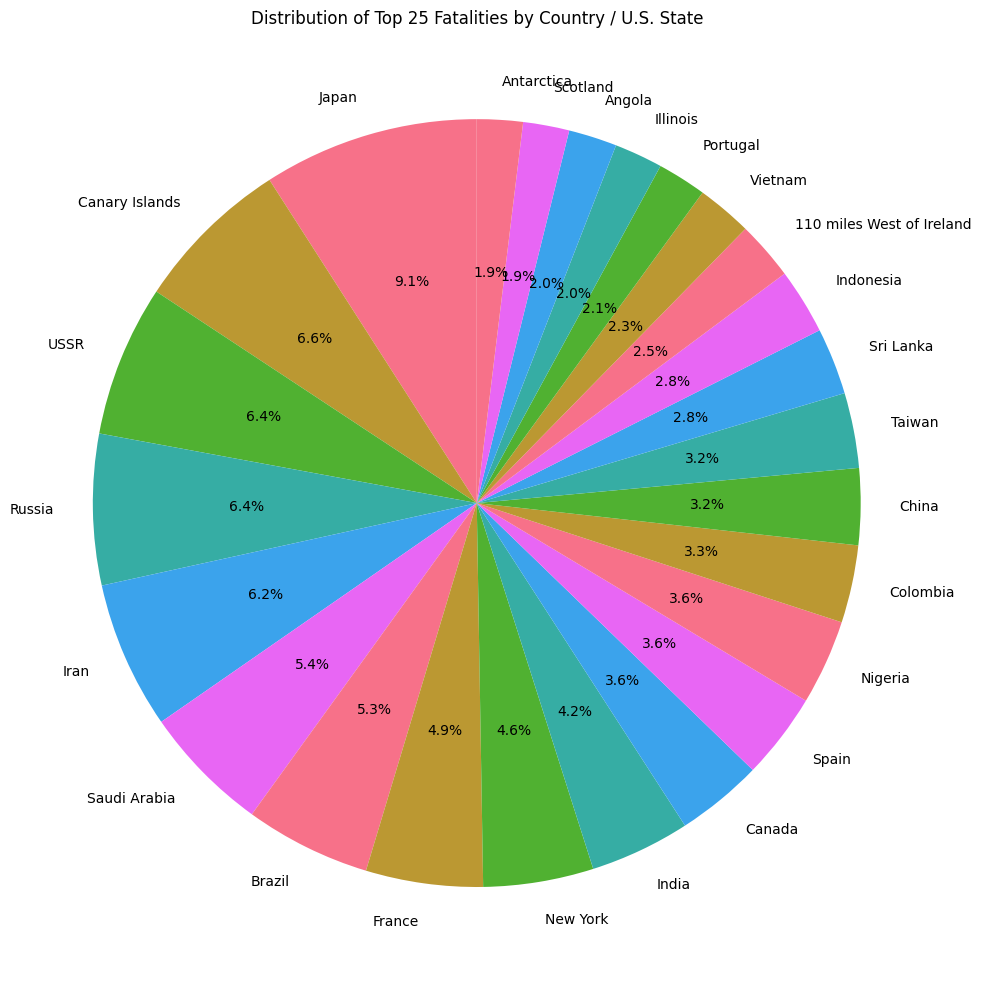

In [ ]:
top_25 = (
    top_100.groupby("State_Country")["Fatalities"]
    .sum()
    .sort_values(ascending=False)
    .head(25)
)

plt.figure(figsize=(10, 10))
sns.set_palette("husl")
plt.pie(top_25.values, labels=top_25.index, autopct="%1.1f%%", startangle=90)
plt.title("Distribution of Top 25 Fatalities by Country / U.S. State")
plt.axis("equal")
plt.tight_layout()
plt.show()

## Groupwork Evidence

Photo of the team working on this assignment together:

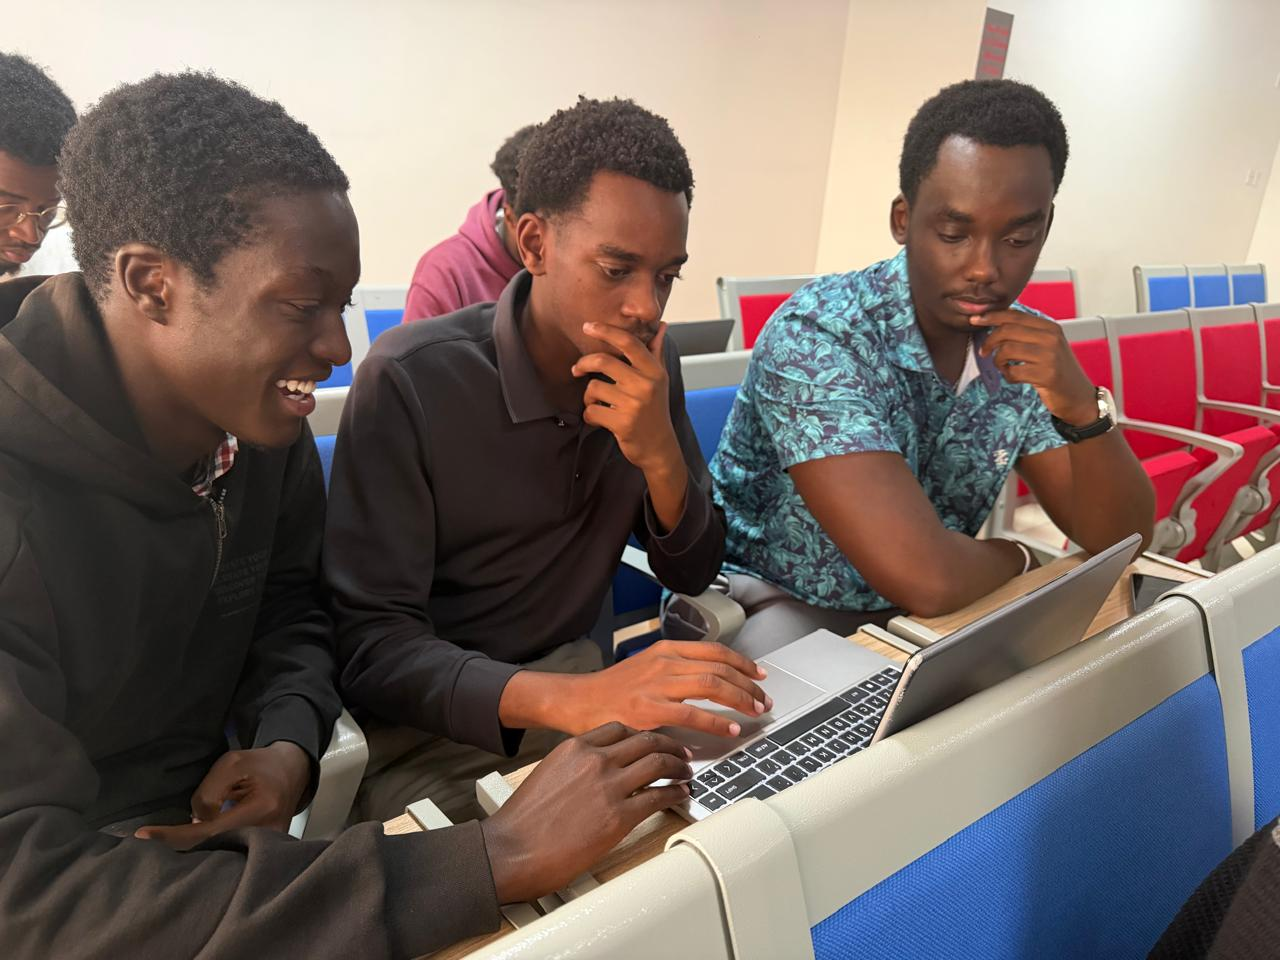